Matplotlib is building the font cache; this may take a moment.


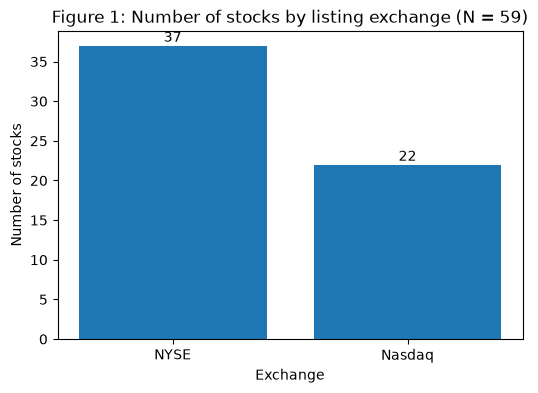

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

profile = pd.read_csv("data/processed/stock_profile.csv", dtype={"cik": str})
counts = profile["exchange"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values)
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")
ax.set_title("Figure 1: Number of stocks by listing exchange (N = 59)")
ax.set_xlabel("Exchange")
ax.set_ylabel("Number of stocks")
fig.savefig("figures/fig1_exchange_bar.png", dpi=200, bbox_inches="tight")

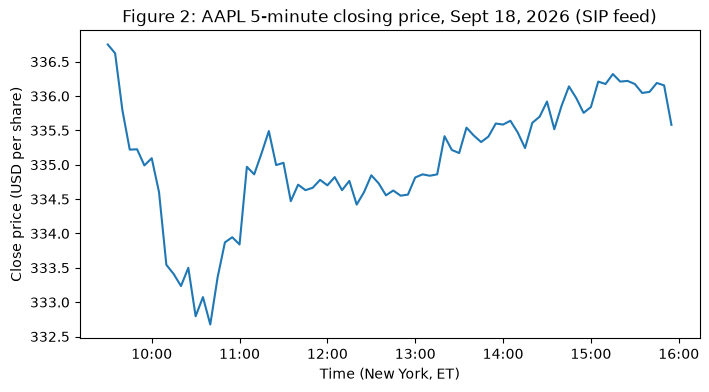

In [2]:
bars = pd.read_csv("data/processed/bars_clean.csv", parse_dates=["bar_start_utc"])
one = bars[(bars["symbol"] == "AAPL") & (bars["session_date"] == "2026-09-18")]
ny_time = one["bar_start_utc"].dt.tz_convert("America/New_York")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ny_time, one["close"])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=ny_time.dt.tz))
ax.set_title("Figure 2: AAPL 5-minute closing price, Sept 18, 2026 (SIP feed)")
ax.set_xlabel("Time (New York, ET)")
ax.set_ylabel("Close price (USD per share)")
fig.savefig("figures/fig2_aapl_price_line.png", dpi=200, bbox_inches="tight")